## Entre dos potentes modelos, como lo es el Baseline y el svm, ¿Cual de estos dos modelos tiene un mejor desempeño en el indicador F1_score con los datos suministrados?
#### unidad de análisis: porcentaje de eficiencia por medio del F1_score

#### target: 95% +  de Acurracy

### ADVERTENCIA: Este ejemplo no constituye un diagnostico médico

In [30]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

bunch = load_breast_cancer(as_frame=True)
X = bunch.data.copy()
y = bunch.target.copy()
print(X.shape)
print(y.value_counts().sort_index())
X.head()

(569, 30)
target
0    212
1    357
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [31]:
audit = pd.DataFrame({
    "tipo": X.dtypes.astype(str),
    "ausentes": X.isna().sum(),
    "unicos":X.nunique()

})

print("Duplicados:", X.duplicated().sum())
print("Target dentro de X:", y.name in X.columns)
audit.head(10)

Duplicados: 0
Target dentro de X: False


,tipo,ausentes,unicos
mean radius,float64,0,456
mean texture,float64,0,479
mean perimeter,float64,0,522
mean area,float64,0,539
mean smoothness,float64,0,474
mean compactness,float64,0,537
mean concavity,float64,0,537
mean concave points,float64,0,542
mean symmetry,float64,0,432
mean fractal dimension,float64,0,499


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

(455, 30) (114, 30)
target
1    0.626
0    0.374
Name: proportion, dtype: float64
target
1    0.632
0    0.368
Name: proportion, dtype: float64


In [33]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print("F1 macro baseline:", f1_score(y_test, dummy_pred, average="macro"))

F1 macro baseline: 0.3870967741935484


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([
    ("scale", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42))
])
svm.fit(X_train, y_train)

,steps,"[('scale', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'


              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



ROC-AUC: 0.995


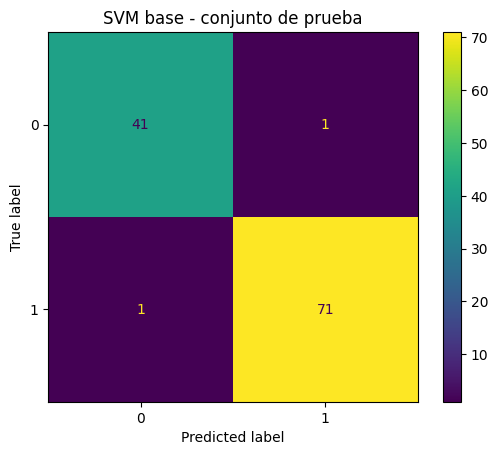

In [35]:
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

pred = svm.predict(X_test)
proba = svm.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("SVM base - conjunto de prueba")
plt.show()

#### Esta matriz de confusión nos brinda los resultados del modelo SVM, donde nos indica los falsos positivos y falsos negativos en un nivel minimamente marcado, mostrando un desempeño excelente del modelo en datos nunca antes vistos y segun el scoring arrojado por el F1_score, este asciende a un 0.98.

## Buscar C y gamma dentro del pipeline

In [36]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(
    estimator=svm,
    param_grid={
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1]
    },
    scoring="f1_macro", cv=cv, n_jobs=-1, return_train_score=True
)
search.fit(X_train, y_train)
print(search.best_params_)
print("CV:", round(search.best_score_, 4))

{'model__C': 10, 'model__gamma': 0.01}
CV: 0.9739


## Comparar sin ocultar variación

In [37]:
cv_results = pd.DataFrame(search.cv_results_)
columns = ["param_model__C", "param_model__gamma",
           "mean_test_score", "std_test_score", "mean_fit_time"]
cv_results[columns].sort_values("mean_test_score", ascending=False).head(9)

best = search.best_estimator_
best_pred = best.predict(X_test)
print(classification_report(y_test, best_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



### Definitivamente, cuando vemos a ambos modelos y sus resultados, nos damos cuenta que mientras el Baseline tiene un F1_score de un 0.38, el UVM tiene ese mismo parametro en un 0.98, lo que implica que el resultado es correcto en el 98 % de los casos.

In [38]:
from pathlib import Path
import joblib
Path("reports").mkdir(exist_ok=True)
cv_results[columns].to_csv("reports/svm_cv_results.csv", index=False)
joblib.dump(best, "reports/svm_best.joblib")

['reports/svm_best.joblib']